# Pre-requisites
- import packages
- download dataset

In [1]:
# import pacakages

# General
import kagglehub # dataset source
import numpy as np # data manip
import pandas as pd # arrays
import shutil
import os
import glob
from PIL import Image
from pathlib import Path
import random

# ML
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision
import torchvision.transforms as transforms
import torch.optim as optim
from torch.utils.data import Subset, DataLoader
from torchvision.transforms import v2
from torchvision.transforms import ToTensor
from torchvision import datasets, transforms, models
# import sklearn
from sklearn.model_selection import StratifiedShuffleSplit


# vis 
import matplotlib.pyplot as plt

# image manip
import cv2 as cv


In [2]:
# import torchvision dataset

data_path = "./data"

dataset = datasets.OxfordIIITPet(root = data_path, download = True )

# Data Exploration and Preprocessing
1. Visualise representative images from each class
2. Convert images to grayscale for the trad BoVW pipeline
3. Normalise image tensors for dl
4. split the dataset into training validation and test sets

In [3]:
img_data_dir = os.path.join(data_path, "oxford-iiit-pet")
print("Image data directory:", img_data_dir)

# Print dataset info
data_size = len(dataset)
num_classes = len(dataset.classes)

print(f"Total samples: {data_size}")
print(f"Number of classes: {num_classes}")
print(f"Classes: {dataset.classes}")

# Count samples per class
from collections import Counter
labels = [dataset[i][1] for i in range(data_size)]
class_counts = Counter(labels)

print("\nSamples per class:")
for class_name, count in sorted(class_counts.items()):
    print(f"  {dataset.classes[class_name]}: {count}")

Image data directory: ./data\oxford-iiit-pet
Total samples: 3680
Number of classes: 37
Classes: ['Abyssinian', 'American Bulldog', 'American Pit Bull Terrier', 'Basset Hound', 'Beagle', 'Bengal', 'Birman', 'Bombay', 'Boxer', 'British Shorthair', 'Chihuahua', 'Egyptian Mau', 'English Cocker Spaniel', 'English Setter', 'German Shorthaired', 'Great Pyrenees', 'Havanese', 'Japanese Chin', 'Keeshond', 'Leonberger', 'Maine Coon', 'Miniature Pinscher', 'Newfoundland', 'Persian', 'Pomeranian', 'Pug', 'Ragdoll', 'Russian Blue', 'Saint Bernard', 'Samoyed', 'Scottish Terrier', 'Shiba Inu', 'Siamese', 'Sphynx', 'Staffordshire Bull Terrier', 'Wheaten Terrier', 'Yorkshire Terrier']

Samples per class:
  Abyssinian: 100
  American Bulldog: 100
  American Pit Bull Terrier: 100
  Basset Hound: 100
  Beagle: 100
  Bengal: 100
  Birman: 100
  Bombay: 96
  Boxer: 100
  British Shorthair: 100
  Chihuahua: 100
  Egyptian Mau: 93
  English Cocker Spaniel: 96
  English Setter: 100
  German Shorthaired: 100
  

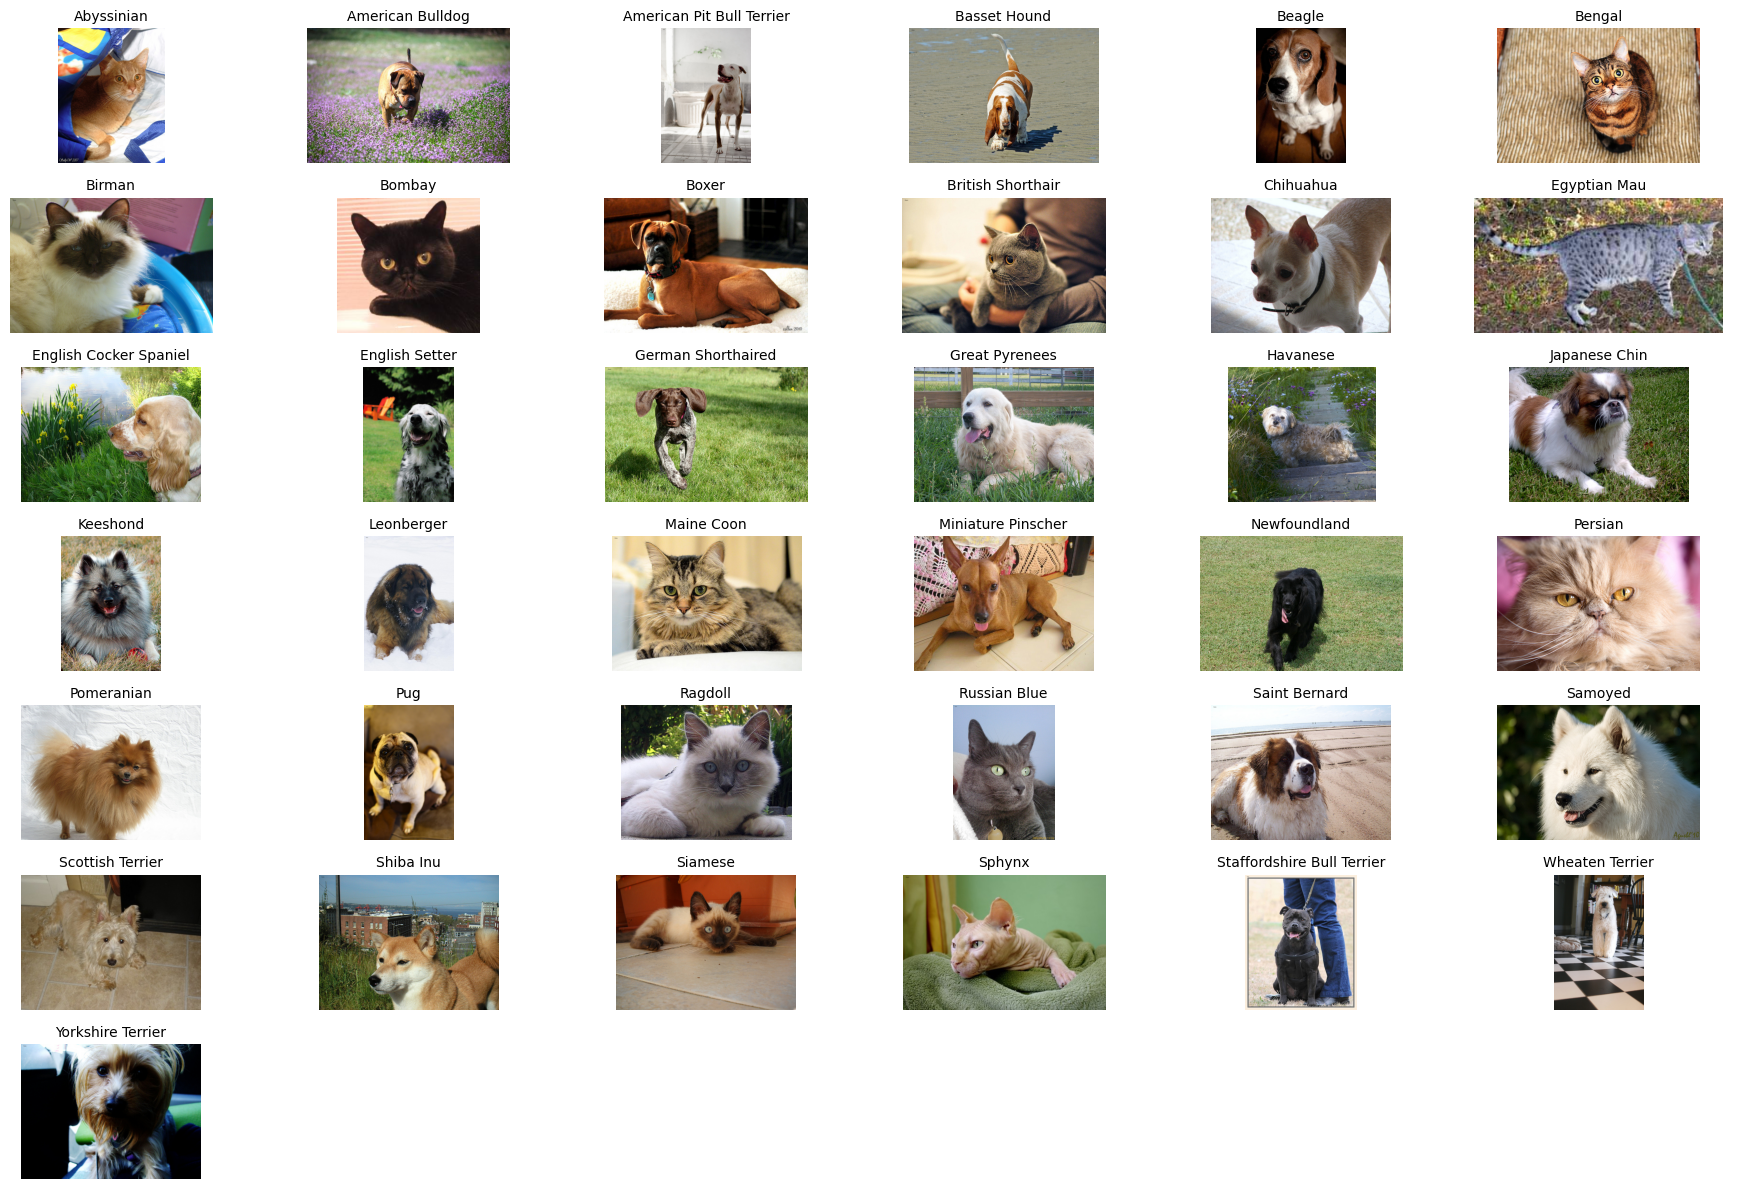

In [4]:
# visualise one image from each class

# get one sample per class
class_samples = {}

for img, label in dataset:
    if label not in class_samples:
        class_samples[label] = img
    if len(class_samples) == num_classes:
        break

# display in a grid
cols = 6
rows = (num_classes + cols - 1) // cols

fig, axes = plt.subplots(rows, cols, figsize=(18, 12))
axes = axes.flatten()

for idx, (class_idx, img) in enumerate(sorted(class_samples.items())):
    ax = axes[idx]
    ax.imshow(img)
    ax.set_title(dataset.classes[class_idx], fontsize=10)
    ax.axis('off')

# hide empty subplots
for idx in range(len(class_samples), len(axes)):
    axes[idx].axis('off')

plt.tight_layout()
plt.show()

In [5]:
# pre-processing operations

# splitting

seed = 42
train_size = 0.7
val_size = 0.15
test_size = 0.15
batch_size = 32
num_workers = 4 # change depending on GPU load


# transformation instructions

orb_transforms = v2.Compose([
    v2.Grayscale(num_output_channels=1), # conv grayscale
    v2.Resize((224, 224)), # resize to fixed size for ORB
])

train_transforms = v2.Compose([
    v2.Grayscale(num_output_channels=1), # conv grayscale 
    v2.RandomResizedCrop(size=(224, 224), antialias=True), # crop to fixed size and maintain qual
    v2.RandomHorizontalFlip(p=0.5), # flip images for better learning
    v2.ToImage(), # convert to tensor
    v2.ToDtype(torch.float32, scale=True), # conv pixel from int to float 
    v2.Normalize(mean=[0.5], std=[0.5]), # normalise using standard val
])

val_test_transforms = v2.Compose([
    v2.Grayscale(num_output_channels=1),
    v2.Resize((224, 224)),
    v2.ToImage(),
    v2.ToDtype(torch.float32, scale=True),
    v2.Normalize(mean=[0.5], std=[0.5]),
])

In [6]:
# Do split operations

# convert to numpy for sklearn ops
indices = np.arange(data_size)
labels_arr = np.array(labels)

# split for test
sss_test = StratifiedShuffleSplit(n_splits=1, test_size=test_size, random_state=seed)
train_val_idx, test_idx = next(sss_test.split(indices, labels_arr))

# split remaining into train and val (70/15/15)

# find the relative size 
val_rel = val_size / (train_size + val_size)  # 0.15 / 0.85 (currently)

# split train_val into train and val using relative size
sss_val = StratifiedShuffleSplit(n_splits=1, test_size=val_rel, random_state=seed)
train_rel_idx, val_rel_idx = next(
    sss_val.split(train_val_idx, labels_arr[train_val_idx])
)

# Map relative indices back to original dataset indices
train_idx = train_val_idx[train_rel_idx]
val_idx = train_val_idx[val_rel_idx]

# verify splits
print(f"Total samples: {data_size}")
print(f"Train samples: {len(train_idx)}")
print(f"Validation samples: {len(val_idx)}")
print(f"Test samples: {len(test_idx)}")
print(f"Check total: {len(train_idx) + len(val_idx) + len(test_idx)}")

# optional sanity check: no overlap
assert set(train_idx).isdisjoint(val_idx)
assert set(train_idx).isdisjoint(test_idx)
assert set(val_idx).isdisjoint(test_idx)

# check maths
fifteen_pct = data_size / 100 * 15 
print(f"15 % of data: {fifteen_pct}")

Total samples: 3680
Train samples: 2576
Validation samples: 552
Test samples: 552
Check total: 3680
15 % of data: 552.0


In [7]:
# now splitting into the respective subsets and for ORB 

orb_base = datasets.OxfordIIITPet(root=data_path, transform=orb_transforms)
train_base = datasets.OxfordIIITPet(root=data_path, transform=train_transforms)
val_test_base = datasets.OxfordIIITPet(root=data_path, transform=val_test_transforms)

orb_ds = Subset(orb_base, train_idx) # only need to do ORB on the training set for now
train_ds = Subset(train_base, train_idx)
val_ds = Subset(val_test_base, val_idx)
test_ds = Subset(val_test_base, test_idx)

train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True, num_workers=num_workers)

val_loader = DataLoader(val_ds, batch_size=batch_size, shuffle=False, num_workers=num_workers)

test_loader = DataLoader(test_ds, batch_size=batch_size, shuffle=False, num_workers=num_workers)

# Feature Extraction using ORB
1. Detect keypoints using the ORB feature detector
2. Extract keypoints from grayscale images
3. Store descriptors for all training images for codebook generation

In [13]:
# initialise ORB detector
orb = cv.ORB_create()  # type: ignore[attr-defined]

# create storage
all_descrip = []

for img, label in orb_ds: # type: ignore (i can ignore..?)
    # orb_ds yields PIL grayscale images here, so convert to uint8 numpy array
    img_np = np.array(img, dtype=np.uint8)

    kp, des = orb.detectAndCompute(img_np, None)
    if des is not None:
        all_descrip.append(des)

print(f"Descriptor sets extracted: {len(all_descrip)} / {len(orb_ds)}")
print(all_descrip[0][0]) # show one descriptor

Descriptor sets extracted: 2576 / 2576
[178  15  46 190  28 128 211 228 148   4 208  35  37 201  51  64 200 251
  27 195 106 171   2 191 241 229 138  11  21  27  52 234]


# Codebook Generation and Representation
Construct visual vocabularies using Mini-Batch K-Means clustering with codebook sizes: [ K = 100, 300,
500 ]

For each value of K:
1. Train the codebook using descriptors from the training set only
2. Represent every image as a normalised histogram of visual words
3. Prepare histogram features for training validation and testing sets

In [16]:
from sklearn.cluster import MiniBatchKMeans

# Stack training descriptors into one array for codebook
all_descrip_stacked = np.vstack(all_descrip)  # shape: (total_keypoints, 32)
print(f"Total training descriptors stacked: {all_descrip_stacked.shape}")

# Extract ORB descriptors + labels for val and test sets
orb_val_ds  = Subset(orb_base, val_idx)
orb_test_ds = Subset(orb_base, test_idx)

Total training descriptors stacked: (951578, 32)


In [17]:
# function for extracting features from orb set
def extract_orb_features(subset):
    """Extract ORB descriptors and labels from a dataset subset.
    Returns (desc_list, labels) where desc_list[i] may be None if no keypoints found."""
    orb_det = cv.ORB_create()  # type: ignore[attr-defined]
    desc_list, label_list = [], []
    for img, label in subset:
        img_np = np.array(img, dtype=np.uint8)
        _, des = orb_det.detectAndCompute(img_np, None)
        desc_list.append(des)
        label_list.append(label)
    return desc_list, np.array(label_list)

In [18]:
# Re-extract train to get per-image labels aligned with descriptors
print("Extracting train descriptors (with labels)...")
train_desc, train_labels_orb = extract_orb_features(orb_ds)
print("Extracting val descriptors...")
val_desc,   val_labels_orb   = extract_orb_features(orb_val_ds)
print("Extracting test descriptors...")
test_desc,  test_labels_orb  = extract_orb_features(orb_test_ds)

Extracting train descriptors (with labels)...
Extracting val descriptors...
Extracting test descriptors...


In [19]:
# normalised BoVW histogram
def build_histograms(desc_list, kmeans, K):
    hists = []
    for des in desc_list:
        if des is not None:
            words = kmeans.predict(des)                        # assign each keypoint to a visual word
            hist, _ = np.histogram(words, bins=K, range=(0, K))
            hist = hist / (hist.sum() + 1e-7)                 # normalise to frequency
        else:
            hist = np.zeros(K, dtype=np.float32)              # no keypoints → zero vector
        hists.append(hist)
    return np.array(hists, dtype=np.float32)

In [20]:
# train codebook and build histogram
codebook_sizes = [100, 300, 500]
bovw_data = {}

for K in codebook_sizes:
    print(f"\nFitting MiniBatchKMeans with K={K}...")
    kmeans = MiniBatchKMeans(n_clusters=K, random_state=seed, batch_size=1024, n_init=3)
    kmeans.fit(all_descrip_stacked)   # fit only on training descriptors

    X_train = build_histograms(train_desc, kmeans, K)
    X_val   = build_histograms(val_desc,   kmeans, K)
    X_test  = build_histograms(test_desc,  kmeans, K)

    bovw_data[K] = {
        'X_train': X_train, 'y_train': train_labels_orb,
        'X_val':   X_val,   'y_val':   val_labels_orb,
        'X_test':  X_test,  'y_test':  test_labels_orb,
        'kmeans':  kmeans,
    }
    print(f"  Train: {X_train.shape}, Val: {X_val.shape}, Test: {X_test.shape}")


Fitting MiniBatchKMeans with K=100...
  Train: (2576, 100), Val: (552, 100), Test: (552, 100)

Fitting MiniBatchKMeans with K=300...
  Train: (2576, 300), Val: (552, 300), Test: (552, 300)

Fitting MiniBatchKMeans with K=500...
  Train: (2576, 500), Val: (552, 500), Test: (552, 500)


# Classification using Traditional Machine Learning 
For each codebook size:
1. Train a Gradient Boosting classifier on the training histogram features.
2. Evaluate the classifier on the validation set using:
- Accuracy
- Precision
- Recall
- F1-score
3. Compare results for K = 100, K = 300, and K = 500.
4. Select the best-performing vocabulary size.
5. Retrain the classifier using training and validation data.
6. Report final performance on the test set and include a confusion matrix.

# Deep Learning Classification
1. Load a pre-trained DenseNet-121 model.
2. Replace the final classification layer for 10 classes.
3. Train (fine-tune) the network using the training dataset.
4. Evaluate performance on the validation and test sets using accuracy, precision, recall, and F1-score.

# Data Augmentation
Apply aerial-image appropriate augmentation:
- Rotation (90°, 180°, 270°)
- Horizontal flipping
- Vertical flipping
- Slight scaling
1. Retrain the DenseNet-121 model using the augmented dataset.
2. Compare performance with the non-augmented CNN model.